# Знакомство с инструментами*

Цель:

- Освоить работу с базовыми инструментами: PyTorch, PyTorch Lightning, TensorBoard.

- Научиться самостоятельно работать с научной литературой.

- Отработать пайплайн проведения экспериментов.

Задача:

На примере датасета MNIST провести сравнительный анализ нескольких оптимизаторов и функций потерь.

План выполнения:

1. Загрузите датасет (код для загрузки приведен в ячейке ниже).

2. Создайте модель: простая нейронная сеть, состоящая из 2–4 полносвязных слоев.

3. Подготовьте данные и создайте код для обучения (учтите, что экспериментов будет несколько).

4. Обучите модель с разными оптимизаторами:

        - SGD
        - SGD + Momentum
        - AdamW
        - Современный оптимизатор на ваш выбор

    Проведите сравнительный анализ результатов обучения. Продумайте критерии для оценки (например, скорость сходимости, итоговая точность, стабильность обучения).

5. Выберите оптимизатор, показавший лучшие результаты. Используя его, обучите модель с разными функциями активации:

       - Sigmoid,
       - Tanh,
       - ReLU,
       - одной современной функцией активации на ваш выбор.

6. По результатам исследования напишите краткий вывод.

Будьте готовы ответить на любые вопросы по коду в блокноте.

P.S. В этом задании скорость выполнения экспериментов важнее, чем абсолютная точность модели. Подумайте над тем, как выстроить удобный пайплайн обучения, который вы сможете использовать в дальнейшем. Использование инструментов для логирования и автоматизации запусков (PyTorch Lightning, TensorBoard) приветствуется, но не является обязательным.

## Загрузка датасета MNIST*

In [ ]:
from torchvision import  transforms, datasets
from torch.utils.data import DataLoader, random_split
import torch
from torch import nn
from torchvision import transforms
from torchvision import datasets
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import time
import numpy as np

In [ ]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize( (0.1307), (0.3081))
     ])

mnist = datasets.MNIST('MNIST', train=True, download=True, transform=transform)
mnist_test = datasets.MNIST('MNIST', train=False, download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 478kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.48MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.66MB/s]


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


torch.Size([1, 28, 28]) 5


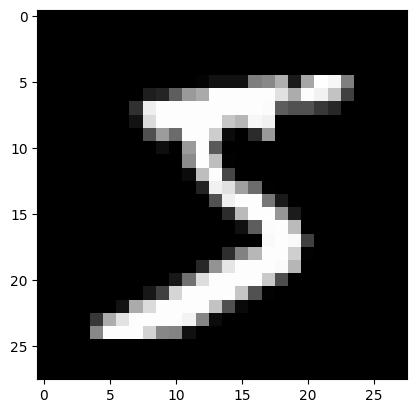

In [ ]:
image_tensor, label = mnist[0]
print(image_tensor.shape, label)
plt.imshow(image_tensor[0,:,:],cmap = 'gray')

In [ ]:
train_ds, val_ds = random_split(mnist, [50000, 10000], generator=torch.Generator().manual_seed(42))

batch_size = 128
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(mnist_test, batch_size=batch_size, shuffle=False)

len(train_ds), len(val_ds), len(mnist_test)

(50000, 10000, 10000)

## Создайте модель

In [ ]:
class ConvNet(nn.Module):
    def __init__(self, activation_func_name = 'relu', num_classes = 10):
        super().__init__()

        activation_func = nn.ReLU()

        if (activation_func_name == 'tanh'):
            activation_func = nn.Tanh()
        elif (activation_func_name == 'sigmoid'):
            activation_func = nn.Sigmoid()
        elif (activation_func_name == 'gelu'):
            activation_func = nn.GELU()
        elif (activation_func_name == 'softplus'):
            activation_func = nn.Softplus()

        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            activation_func,
            nn.MaxPool2d(2),
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            activation_func,
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(16*49, 64),
            activation_func,
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        return self.features(x)

## Подготовьте код для обучения

In [ ]:
def get_optim(model, optimizer_name):
    if (optimizer_name == 'sgd'):
        return torch.optim.SGD(model.parameters(), lr=0.01)
    elif (optimizer_name == 'adam'):
        return torch.optim.Adam(model.parameters(), lr=0.001)
    elif (optimizer_name == 'adamw'):
        return torch.optim.AdamW(model.parameters(), lr=0.001)
    elif (optimizer_name == 'asgd'):
        return torch.optim.ASGD(model.parameters(), lr=0.01)

In [ ]:
def train_model(activation_func_name, optimizer_name):
    model = ConvNet(activation_func_name=activation_func_name).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = get_optim(model, optimizer_name)
    EPOCHES=3

    history = {"val_loss": [], "val_acc": [], "time": []}
    start_t = time.time()

    for epoch in range(EPOCHES):
        print(f'Epoch {epoch}')
        start_t = time.time()
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

        model.eval()
        total_loss = 0
        total_acc = 0
        b = 0
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            preds = logits.argmax(dim=1)
            loss = criterion(logits, y)
            total_loss += loss.item()
            total_acc += (preds == y).float().mean().item()
            b += 1

        epoch_time = time.time() - start_t
        history["val_loss"].append(total_loss)
        history["val_acc"].append(total_acc)
        history["time"].append(epoch_time)

        if (epoch > 0 and history["val_loss"][-2] <= history["val_loss"][-1]):
            print('Лосс уменьшается не стабильно')

        print(f'val_loss: {total_loss / b}, val_acc: {total_acc / b}, time {epoch_time}')

    val_acc = np.array(history["val_acc"], dtype=float)
    epochs_to_95 = 999999
    best_acc = float(val_acc.max())
    target_acc = best_acc * 0.95
    for i, a in enumerate(val_acc, start=1):
        if a >= target_acc:
            epochs_to_95 = i
            break
    print(f'epoches to 0.95 accuracy: {epochs_to_95}')
    print(f'\t FINAL val_loss: {total_loss / b}, val_acc: {total_acc / b}, total_time: {sum(history['time'])}')

## Тест оптимизаторов

Обучите модель с разными оптимизаторами:
- SGD,
- SGD + momentum,
- AdamW
- современный оптимизмтор по вашему выбору


Проведите сравнительный анализ результатов обучения. Подумайте о критериях оценки.

In [ ]:
optims = ['asgd', 'sgd', 'adam', 'adamw']

for optim in optims:
    print(f'============= Optim: {optim} ==============')
    train_model('relu', optim)
    print('============================================')

============= Optim: asgd ==============
Epoch 0
val_loss: 0.4372001260141783, val_acc: 0.8708465189873418, time 13.539341926574707
Epoch 1
val_loss: 0.28555346629287626, val_acc: 0.915743670886076, time 13.438554286956787
Epoch 2
val_loss: 0.23724345495051977, val_acc: 0.9305775316455697, time 13.804452657699585
epoches to 0.95 accuracy: 2
	 FINAL val_loss: 0.23724345495051977, val_acc: 0.9305775316455697, total_time: 40.78234887123108
============= Optim: sgd ==============
Epoch 0
val_loss: 0.5892098444172099, val_acc: 0.7986550632911392, time 13.033499717712402
Epoch 1
val_loss: 0.33732188313822203, val_acc: 0.8988330696202531, time 12.844028234481812
Epoch 2
val_loss: 0.25875720117665546, val_acc: 0.9210838607594937, time 12.818156957626343
epoches to 0.95 accuracy: 2
	 FINAL val_loss: 0.25875720117665546, val_acc: 0.9210838607594937, total_time: 38.69568490982056
============= Optim: adam ==============
Epoch 0
val_loss: 0.12371901285987866, val_acc: 0.9638053797468354, time 13.3

# Тест лосс-функций



Выберите оптимизатор показавший лучшие результаты.
Используя его Обучите модель с разными функциями активации:
- Sigmoid
- Tanh
- Relu
- <современная лосс-функция по вашему выбору>











In [ ]:
loss_fs = ['sigmoid', 'tanh', 'relu', 'gelu', 'softplus']

for loss_f in loss_fs:
    print(f'============= Loss function: {loss_f} ==============')
    train_model(loss_fs, 'adamw')
    print('============================================')

============= Loss function: sigmoid ==============
Epoch 0
val_loss: 0.12955634479847136, val_acc: 0.9609375, time 15.699766635894775
Epoch 1
val_loss: 0.07984483930506284, val_acc: 0.9760680379746836, time 14.576382637023926
Epoch 2
val_loss: 0.07421757718194512, val_acc: 0.9779469936708861, time 13.613127946853638
Epoch 3


KeyboardInterrupt: 

#Вывод

Среди оптимизаторов самый лучший - AdamW.

Везде обучение стабильно, ошибка на валидации всегда уменьшается. Т.е модель не преобучается (лосс не растет).

По времени быстрее всего работает SGD

Быстрее сходятся Adam и AdamW

Я случайно потерял полный вывод, т.к не успевал по времени.